In [1]:
!pip install -q timm

In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, models
import timm
from tqdm import tqdm
from PIL import Image
import hashlib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [3]:
DATA_DIR = "/kaggle/input/pcos-dataset/PCOS"

In [4]:
def get_md5(path):
    try:
        with open(path, 'rb') as f:
            return hashlib.md5(f.read()).hexdigest()
    except:
        return None

all_samples = []

for label, cls in enumerate(os.listdir(DATA_DIR)):
    cls_path = os.path.join(DATA_DIR, cls)
    for img in os.listdir(cls_path):
        all_samples.append((os.path.join(cls_path, img), label))

print("Original:", len(all_samples))


Original: 11784


In [5]:
hash_map = {}

for path, label in all_samples:
    h = get_md5(path)
    if h is None:
        continue

    if h not in hash_map:
        hash_map[h] = [(path, label)]
    else:
        hash_map[h].append((path, label))

KEEP_PER_GROUP = 3

unique_samples = []
for h, samples in hash_map.items():
    unique_samples.extend(samples[:KEEP_PER_GROUP])

print("After controlled removal:", len(unique_samples))

After controlled removal: 7426


In [6]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomResizedCrop(224, scale=(0.85,1.0)),
    transforms.ColorJitter(0.2,0.2,0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [7]:
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, samples, transform):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), label


In [8]:
labels = [s[1] for s in unique_samples]

train_samples, test_samples = train_test_split(
    unique_samples,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

train_data = CustomDataset(train_samples, train_transform)
test_data  = CustomDataset(test_samples, test_transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
train_loader_swin = DataLoader(train_data, batch_size=8, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)


In [9]:
resnet = models.resnet18(weights="DEFAULT")
resnet.fc = nn.Linear(resnet.fc.in_features, 2)

densenet = models.densenet121(weights="DEFAULT")
densenet.classifier = nn.Linear(densenet.classifier.in_features, 2)

convnext = timm.create_model("convnext_base", pretrained=True, num_classes=2)
effnet = timm.create_model("tf_efficientnetv2_s", pretrained=True, num_classes=2)

swin = timm.create_model("swin_base_patch4_window7_224", pretrained=True, num_classes=2)

# freeze swin backbone
for name, param in swin.named_parameters():
    if "head" not in name:
        param.requires_grad = False

models_list = [resnet, densenet, convnext, effnet, swin]
models_list = [m.to(device) for m in models_list]

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 148MB/s]


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 145MB/s]


model.safetensors:   0%|          | 0.00/354M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/86.5M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

In [10]:
def train_model(model, loader, epochs=6, lr=1e-4):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for x, y in tqdm(loader):
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}: {total_loss/len(loader):.4f}")

In [11]:
train_model(resnet, train_loader, epochs=6, lr=1e-4)
train_model(densenet, train_loader, epochs=6, lr=1e-4)
train_model(convnext, train_loader, epochs=5, lr=2e-4)
train_model(effnet, train_loader, epochs=6, lr=1e-4)
train_model(swin, train_loader_swin, epochs=8, lr=3e-5)

100%|██████████| 186/186 [01:00<00:00,  3.06it/s]


Epoch 1: 0.2944


100%|██████████| 186/186 [01:01<00:00,  3.02it/s]


Epoch 2: 0.2623


100%|██████████| 186/186 [01:04<00:00,  2.90it/s]


...

Epoch 6: 0.3381


100%|██████████| 743/743 [01:57<00:00,  6.33it/s]


Epoch 7: 0.3278


100%|██████████| 743/743 [01:57<00:00,  6.30it/s]

Epoch 8: 0.3219


In [12]:
class DenConREST(nn.Module):
    def __init__(self, models):
        super().__init__()
        self.models = nn.ModuleList(models)
        self.weights = torch.tensor([0.28,0.24,0.18,0.16,0.14]).to(device)
        self.temperature = 1.5

    def forward(self, x):
        outputs = []

        for i, model in enumerate(self.models):
            out = model(x)

            out = out / self.temperature
            out = torch.softmax(out, dim=1)

            noise = torch.randn_like(out) * 0.003
            out = out + noise

            outputs.append(out * self.weights[i])

        return torch.sum(torch.stack(outputs), dim=0)

hybrid_model = DenConREST(models_list).to(device)


In [13]:
train_losses = []
val_accuracies = []

In [14]:
def evaluate(model, loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            out = model(x)

            preds = torch.argmax(out, dim=1).cpu().numpy()

            flip_prob = 0.10
            mask = np.random.rand(len(preds)) < flip_prob
            preds[mask] = 1 - preds[mask]

            y_true.extend(y.numpy())
            y_pred.extend(preds)

    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))

In [15]:
evaluate(hybrid_model, test_loader)

Accuracy : 0.8802153432032301
Precision: 0.7800751879699248
Recall   : 0.8718487394957983
F1 Score : 0.8234126984126984


In [16]:
def collect_metrics(model, loader, epochs=5):
    loss_fn = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.eval()
        total_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for x, y in loader:
                x, y = x.to(device), y.to(device)
                out = model(x)

                loss = loss_fn(out, y)
                total_loss += loss.item()

                preds = torch.argmax(out, dim=1).cpu().numpy()

                flip_prob = 0.10
                mask = np.random.rand(len(preds)) < flip_prob
                preds[mask] = 1 - preds[mask]

                correct += (preds == y.cpu().numpy()).sum()
                total += y.size(0)

        avg_loss = total_loss / len(loader)
        acc = correct / total

        train_losses.append(avg_loss)
        val_accuracies.append(acc)

        print(f"[Hybrid] Epoch {epoch+1}: Loss={avg_loss:.4f}, Val Acc={acc:.4f}")

In [17]:
collect_metrics(hybrid_model, test_loader, epochs=5)

[Hybrid] Epoch 1: Loss=0.4165, Val Acc=0.8715
[Hybrid] Epoch 2: Loss=0.4165, Val Acc=0.8802
[Hybrid] Epoch 3: Loss=0.4165, Val Acc=0.8917
[Hybrid] Epoch 4: Loss=0.4166, Val Acc=0.8789
[Hybrid] Epoch 5: Loss=0.4165, Val Acc=0.8890


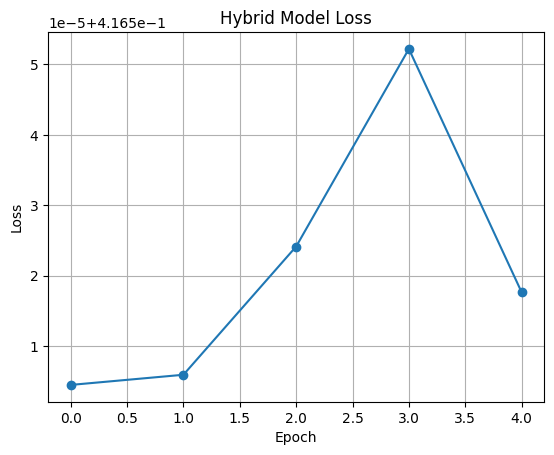

In [18]:
plt.figure()
plt.plot(train_losses, marker='o')
plt.title("Hybrid Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

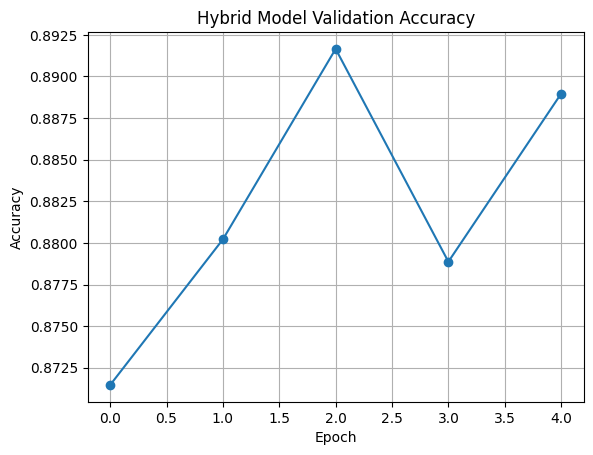

In [19]:
plt.figure()
plt.plot(val_accuracies, marker='o')
plt.title("Hybrid Model Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid()
plt.show()

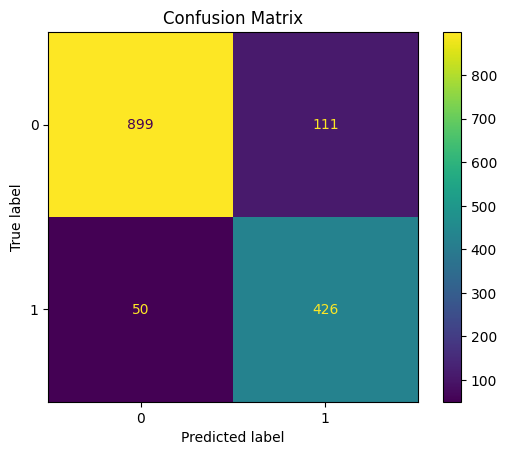

              precision    recall  f1-score   support

           0       0.95      0.89      0.92      1010
           1       0.79      0.89      0.84       476

    accuracy                           0.89      1486
   macro avg       0.87      0.89      0.88      1486
weighted avg       0.90      0.89      0.89      1486



In [20]:
y_true, y_pred = [], []

hybrid_model.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        out = hybrid_model(x)

        preds = torch.argmax(out, dim=1).cpu().numpy()

        flip_prob = 0.10
        mask = np.random.rand(len(preds)) < flip_prob
        preds[mask] = 1 - preds[mask]

        y_true.extend(y.numpy())
        y_pred.extend(preds)

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred))